<a href="https://colab.research.google.com/github/m-fatahillah/PCVK26_15_FATAH/blob/main/Week3_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##IDENTITAS



In [98]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'MUHAMMAD FATAHILLAH ATHABRANI'
NIM = '244107020121'

N = int(NIM[-3:])
PARAM = {
    'b' : (N % 61) + 20,
    'a' : round(1.0 + (N % 9) / 10, 1),
    'c' : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s: %s' % (k, v))
print('WAKTU :', waktu.strftime("%Y-%m-%d %H:%M:%S %Z"))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : MUHAMMAD FATAHILLAH ATHABRANI
NIM  : 244107020121 | N = 121
b     : 80
a     : 1.4
c     : 31
gamma : 0.65
bit   : 3
WAKTU : 2026-09-18 19:33:27 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : dea62dfcfc674565


In [99]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

def show_img(img, title, cmap_type=None):
    plt.figure(figsize=(7,7))
    if len(img.shape) == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray' if cmap_type is None else cmap_type)
    plt.title(f"{NIM} - {title}")
    plt.axis('off')
    plt.show()

# Membaca gambar langsung dari root folder Google Colab
img_ktm1a = cv.imread('gelap.jpeg')
img_ktm1b = cv.imread('matahari.jpeg')
img_ktm1c = cv.imread('lampu ruangan.jpeg')
img_ktm1d = cv.imread('flash.jpeg')
img_obj = cv.imread('OBJ.jpeg')
img_night = cv.imread('NIGHT.jpeg')


## Praktikum E1

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


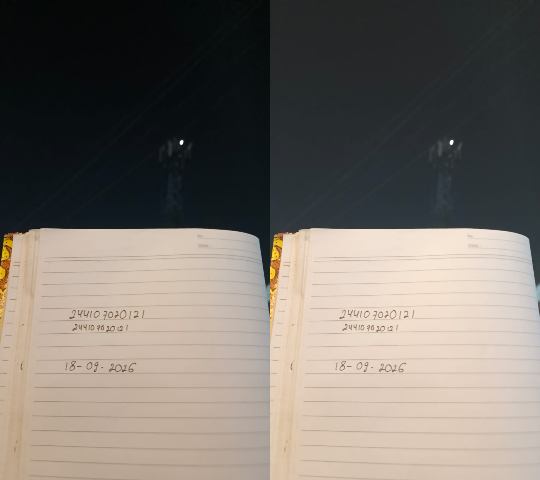

In [100]:
# Transformasi Linier Brightness
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK2026/NIGHT1.jpeg')
# Resize images to 30% dari gambar asli agar tidak lama saat di loop per piksel
original = cv.resize(original, (0, 0), fx=0.3, fy=0.3)

brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            # Cast ke float biar gak overflow pas ditambah sebelum di clip
            pixel_val = float(original[y,x,c]) + brightness
            brightness_image[y,x,c] = np.clip(pixel_val, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## Tugas 1  : inverse citra


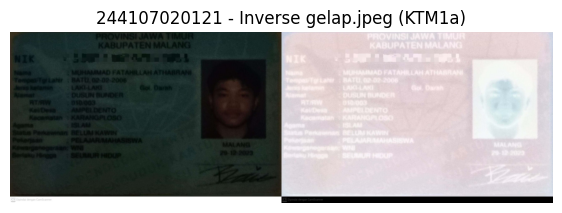

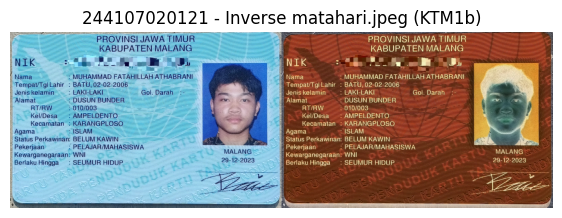

In [101]:
inv_ktm1a = 255 - img_ktm1a
inv_ktm1b = 255 - img_ktm1b

show_img(cv.hconcat([img_ktm1a, inv_ktm1a]), 'Inverse gelap.jpeg (KTM1a)')
show_img(cv.hconcat([img_ktm1b, inv_ktm1b]), 'Inverse matahari.jpeg (KTM1b)')

## TUGAS 2 : Transformasi kontras


Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan : 80
Masukkan kontras : 1.4


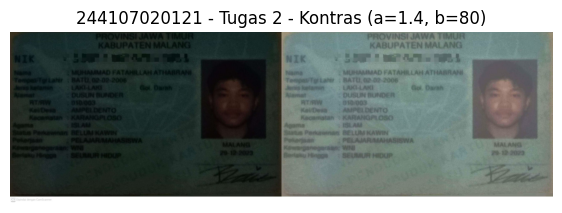

In [102]:
a = PARAM['a']
b = PARAM['b']

print("Mengubah kontras dan tingkat kecerahan citra")
print("--------------------------------------------")
print(f"Masukkan tingkat kecerahan : {b}")
print(f"Masukkan kontras : {a}")

contrast_img = np.clip(a * img_ktm1a.astype(np.float32) + b, 0, 255).astype(np.uint8)
show_img(cv.hconcat([img_ktm1a, contrast_img]), f'Tugas 2 - Kontras (a={a}, b={b})')

## TUGAS 3 : Transformasi Logarithmic Brightness


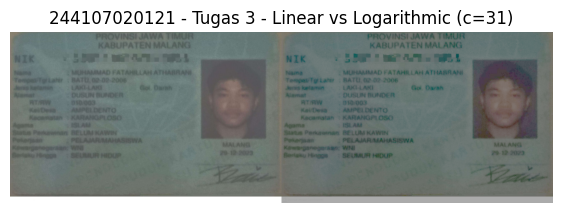

In [103]:
b = PARAM['b']
c_param = PARAM['c']

linear_img = np.clip(img_ktm1a.astype(np.int16) + b, 0, 255).astype(np.uint8)
log_img = np.clip(c_param * np.log1p(img_ktm1a.astype(np.float32)), 0, 255).astype(np.uint8)

show_img(cv.hconcat([linear_img, log_img]), f'Tugas 3 - Linear vs Logarithmic (c={c_param})')

## Tugas 4 : Operasi Grayscale

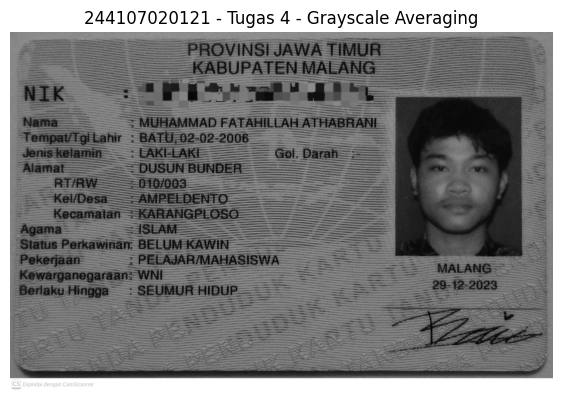

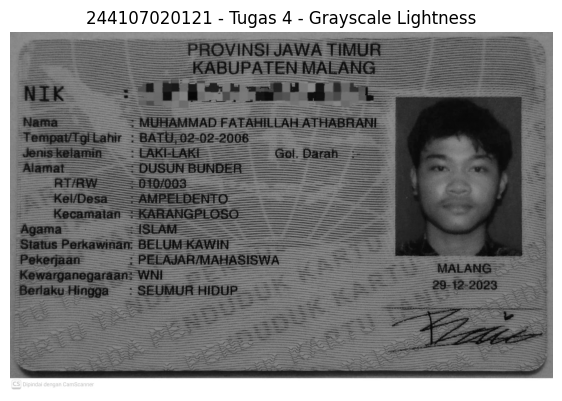

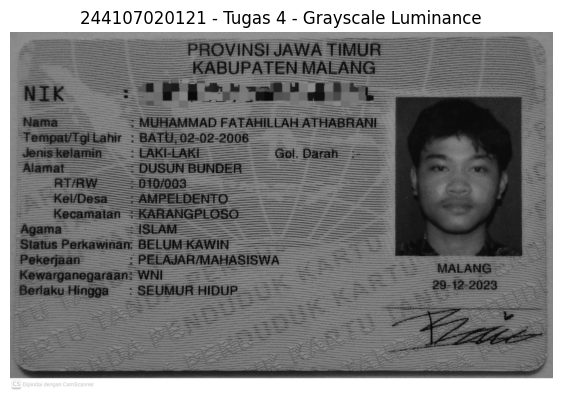

In [104]:
B, G, R = cv.split(img_ktm1c)

gray_avg = ((R.astype(float) + G.astype(float) + B.astype(float)) / 3).astype(np.uint8)
gray_light = ((np.maximum(np.maximum(R,G), B).astype(float) + np.minimum(np.minimum(R,G), B).astype(float)) / 2).astype(np.uint8)
gray_lum = (0.21*R.astype(float) + 0.72*G.astype(float) + 0.07*B.astype(float)).astype(np.uint8)

show_img(gray_avg, 'Tugas 4 - Grayscale Averaging')
show_img(gray_light, 'Tugas 4 - Grayscale Lightness')
show_img(gray_lum, 'Tugas 4 - Grayscale Luminance')

## Tugas 5 : Image Masking (Warna Dominan)

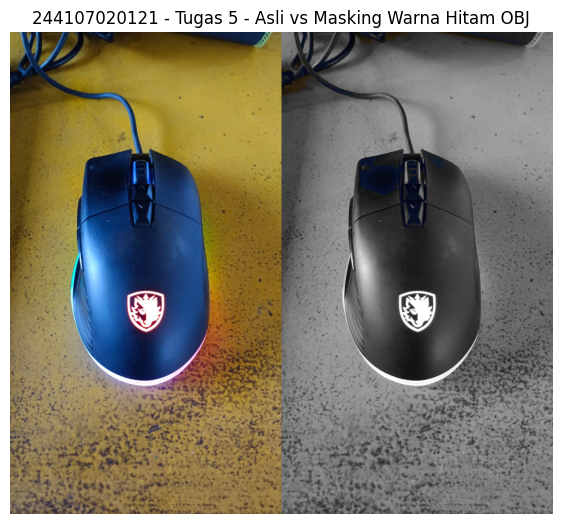

In [105]:
hsv_img = cv.cvtColor(img_obj, cv.COLOR_BGR2HSV)

lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 50])
mask_color = cv.inRange(hsv_img, lower_black, upper_black)

gray_obj = cv.cvtColor(img_obj, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray_obj, cv.COLOR_GRAY2BGR)

# Gabungkan: Area hitam tetap berwarna asli, sisanya menjadi grayscale
res_obj = np.where(mask_color[:,:,None] == 255, img_obj, gray_3ch)

# Tampilkan gambar asli di kiri dan hasil masking di kanan
final_obj = cv.hconcat([img_obj, res_obj])
show_img(final_obj, 'Tugas 5 - Asli vs Masking Warna Hitam OBJ')

## Tugas 6 : Gamma Correction

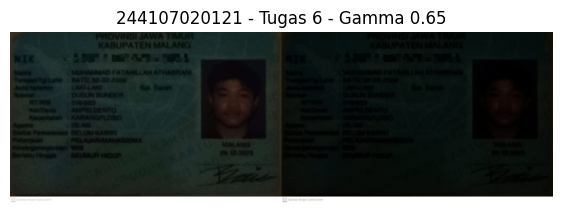

In [106]:
gamma_val = PARAM['gamma']
table = np.array([((i / 255.0) ** (1.0 / gamma_val)) * 255 for i in np.arange(0, 256)]).astype("uint8")
res_gamma = cv.LUT(img_ktm1a, table)

show_img(cv.hconcat([img_ktm1a, res_gamma]), f'Tugas 6 - Gamma {gamma_val}')

## Tugas 7 : Simulasi Image Depth

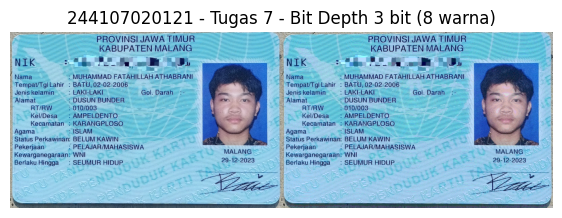

In [107]:
bit = PARAM['bit']
levels = 2 ** bit
factor = 255 / (levels - 1)

bit_img = (np.round(img_ktm1b / 255 * (levels - 1)) * factor).astype(np.uint8)
show_img(cv.hconcat([img_ktm1b, bit_img]), f'Tugas 7 - Bit Depth {bit} bit ({levels} warna)')

## Tugas 8 : Average Denoising

✅ Berhasil memuat 100 gambar noise.
----------------------------------------
Jumlah Citra: 10 | Nilai PSNR: 19.73 dB
Jumlah Citra: 20 | Nilai PSNR: 19.84 dB
Jumlah Citra: 40 | Nilai PSNR: 19.89 dB
Jumlah Citra: 80 | Nilai PSNR: 19.92 dB
Jumlah Citra: 100 | Nilai PSNR: 19.92 dB


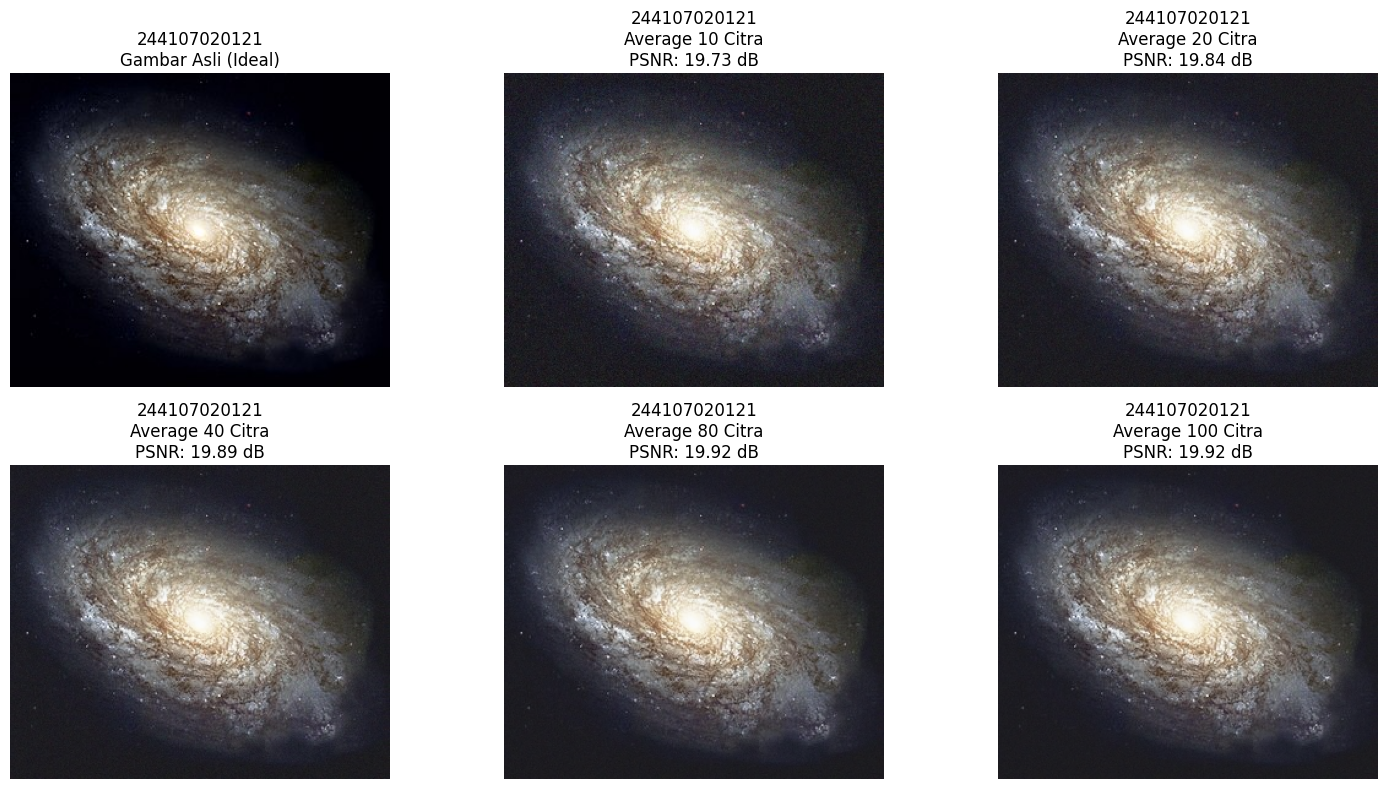

In [108]:
import glob
import cv2 as cv
import numpy as np
from math import log10, sqrt
import matplotlib.pyplot as plt

# Fungsi untuk menghitung PSNR
def PSNR(img1, img2):
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    return 20 * log10(255.0 / sqrt(mse)) if mse != 0 else float('inf')

path_noises = '/content/drive/MyDrive/PCVK2026/noises/*.jpg'
path_ideal = '/content/drive/MyDrive/PCVK2026/galaxy(1).jpg'

cv_img = []
# Membaca semua gambar noise di dalam folder
for img in glob.glob(path_noises):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

# Membaca gambar referensi asli (ideal)
img_ideal = cv.imread(path_ideal)

# Pengecekan apakah gambar berhasil dimuat
if len(cv_img) == 0 or img_ideal is None:
    print("❌ Gambar tidak ditemukan! Pastikan path folder noises dan galaxy.jpg sudah benar.")
else:
    print(f"✅ Berhasil memuat {len(cv_img)} gambar noise.")
    print("-" * 40)

    # Siapkan frame plot untuk 6 gambar (1 asli + 5 hasil average) dengan grid 2 baris 3 kolom
    plt.figure(figsize=(15, 8))

    # Tampilkan citra asli (ideal) di urutan ke-1
    plt.subplot(2, 3, 1)
    plt.imshow(cv.cvtColor(img_ideal, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM}\nGambar Asli (Ideal)")
    plt.axis('off')

    counts = [10, 20, 40, 80, 100]

    # Loop rata-rata citra dan plot urutan ke-2 sampai ke-6
    for i, count in enumerate(counts):
        if count <= len(cv_img):
            # Proses merata-rata citra (Averaging)
            avg_img = np.mean(cv_img[:count], axis=0).astype(np.uint8)

            # Hitung nilai PSNR
            psnr_val = PSNR(img_ideal, avg_img)
            print(f"Jumlah Citra: {count} | Nilai PSNR: {psnr_val:.2f} dB")

            # Plot tiap hasil average
            plt.subplot(2, 3, i + 2)
            plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
            plt.title(f"{NIM}\nAverage {count} Citra\nPSNR: {psnr_val:.2f} dB")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

## Tugas 9 - Image Masking Logika (Sensor KTP)

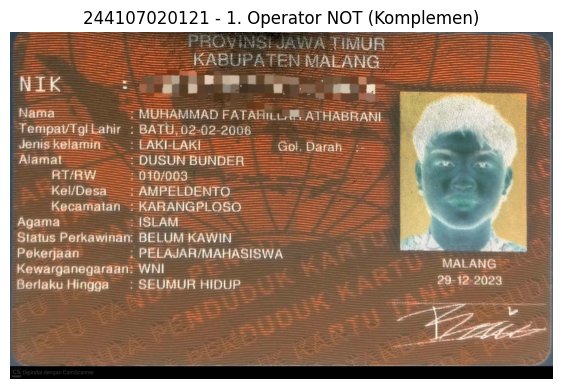

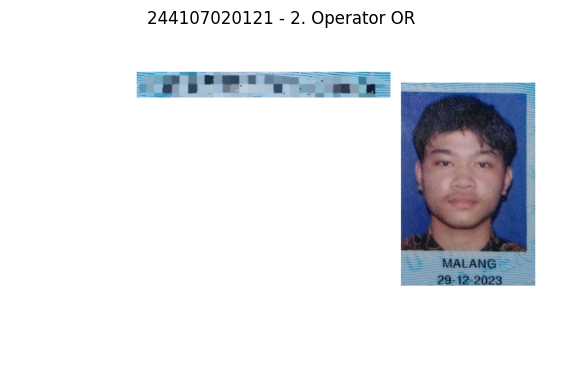

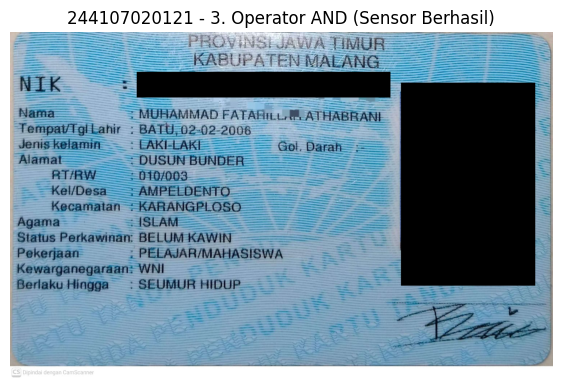

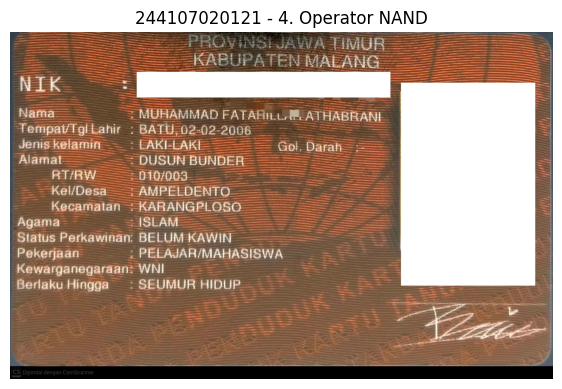

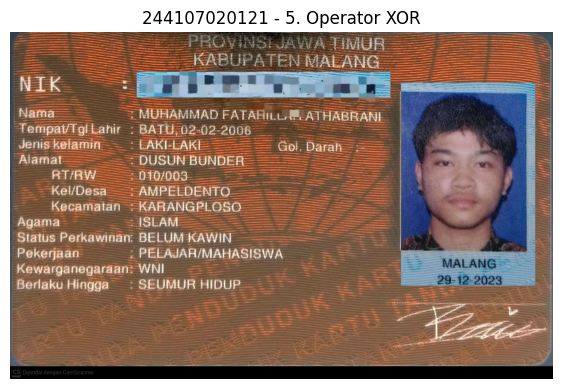

In [109]:
# Membuat mask: Latar putih (255)
mask_ktp = np.ones(img_ktm1d.shape[:2], dtype="uint8") * 255

# Membuat kotak hitam (0) pada area Data Diri dan Pas Foto
cv.rectangle(mask_ktp, (350, 110), (1050, 180), 0, -1)
cv.rectangle(mask_ktp, (1080, 140), (1450, 700), 0, -1)

# Karena operasi bitwise selain AND/NOT sering butuh dimensi sama (3 channel),
# convert mask 1-channel (grayscale) ke 3-channel (BGR)
mask_3ch = cv.cvtColor(mask_ktp, cv.COLOR_GRAY2BGR)

# 1. NOT (Komplemen) - Hanya butuh 1 input gambar
res_not = cv.bitwise_not(img_ktm1d)

# 2. OR (Atau)
res_or = cv.bitwise_or(img_ktm1d, mask_3ch)

# 3. AND (Dan)
res_and = cv.bitwise_and(img_ktm1d, mask_3ch)

# 4. NAND (Not And) - Kebalikan dari AND
res_nand = cv.bitwise_not(res_and)

# 5. XOR (Exclusive Or)
res_xor = cv.bitwise_xor(img_ktm1d, mask_3ch)

# Menampilkan semua hasil untuk tabel laporan
show_img(res_not, '1. Operator NOT (Komplemen)')
show_img(res_or, '2. Operator OR')
show_img(res_and, '3. Operator AND (Sensor Berhasil)')
show_img(res_nand, '4. Operator NAND')
show_img(res_xor, '5. Operator XOR')

## Tugas 10 : Perbaikan Pencahayaan

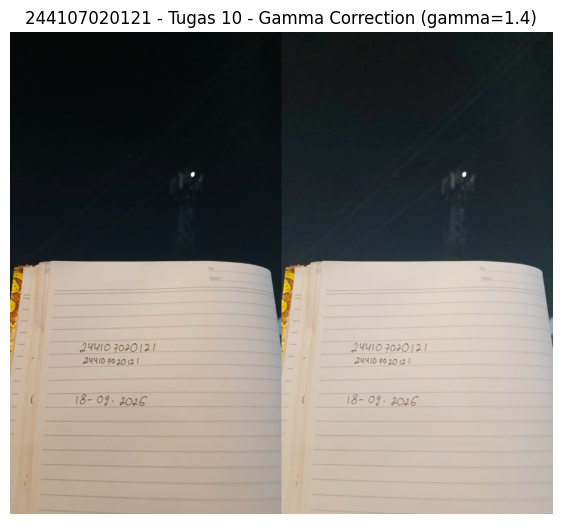

In [110]:
# Menggunakan Gamma Correction dengan nilai yang lebih moderat agar tidak overexposure

g_night = 1.4
table_night = np.array([((i / 255.0) ** (1.0 / g_night)) * 255 for i in np.arange(0, 256)]).astype("uint8")
res_night_gamma = cv.LUT(img_night, table_night)

show_img(cv.hconcat([img_night, res_night_gamma]), f'Tugas 10 - Gamma Correction (gamma={g_night})')